# Quantum-Enhanced Feature Selection for Solar Generation Forecasting
### Reproducible experiment notebook

This notebook contains the **complete, executable pipeline** behind the manuscript
*"A Quantum-Enhanced Feature-Selection Framework for Solar Photovoltaic Generation
Forecasting: Classical, Quantum-Inspired, and Gate-Based Optimization."*

Every number reported in the paper is produced by the cells below and written to
`results.json`. We formulate wrapper feature selection as a **QUBO** and solve the
*identical* problem with six optimizers — **GA, PSO** (classical), **QPSO, QIEA,
QGA** (quantum-inspired), and **QAOA** (gate-based, simulated with PennyLane) —
then evaluate the selected features on (i) a **HistGradientBoosting** forecasting
task and (ii) a 4-qubit **Variational Quantum Classifier (VQC)**. Ablation studies,
a radar comparison, and the architecture diagram close the study.

**Dataset:** `solar_weather.csv` (place it next to this notebook). 196,776 rows at
15-minute resolution (2017-01-01 → 2022-08-31), target `Energy delta[Wh]`.

**Dependencies:** `numpy pandas scikit-learn matplotlib pennylane`.


## 1. Setup and configuration

In [1]:
# ============================================================================
# SECTION A — Setup, configuration, data loading, EDA
# ============================================================================
import json, time, warnings
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
warnings.filterwarnings("ignore")

import pennylane as qml
from pennylane import numpy as pnp
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.edgecolor": "#333333",
    "axes.linewidth": 0.9, "font.family": "DejaVu Sans",
})
NAVY, BLUE, RED, GREEN, ORANGE, PURPLE = (
    "#0b1f4d", "#1f6feb", "#d1495b", "#2a9d8f", "#e9973f", "#7b4fb0")
FIGDIR = "figures"

DATA_PATH = "solar_weather.csv"
TARGET = "Energy delta[Wh]"
CANDIDATE_FEATURES = [
    "GHI", "temp", "pressure", "humidity", "wind_speed", "rain_1h",
    "snow_1h", "clouds_all", "isSun", "sunlightTime", "dayLength",
    "SunlightTime/daylength", "weather_type", "hour", "month",
]

## 2. Data loading and exploratory analysis
We load the dataset, confirm it is complete (no missing values or duplicates), and summarise the target distribution and feature–target correlations.

In [2]:
df = pd.read_csv(DATA_PATH)
df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time").reset_index(drop=True)

DATA_INFO = dict(
    n_rows=int(df.shape[0]), n_cols=int(df.shape[1]),
    t_start=str(df["Time"].min()), t_end=str(df["Time"].max()),
    n_missing=int(df.isnull().sum().sum()), n_dupes=int(df.duplicated().sum()),
    target_mean=float(df[TARGET].mean()), target_std=float(df[TARGET].std()),
    target_max=float(df[TARGET].max()), zero_frac=float((df[TARGET] == 0).mean()),
    issun_frac=float((df["isSun"] == 1).mean()),
)
print("Rows x Cols :", DATA_INFO["n_rows"], "x", DATA_INFO["n_cols"])
print("Time range  :", DATA_INFO["t_start"], "->", DATA_INFO["t_end"])
print("Missing     :", DATA_INFO["n_missing"], "| Duplicates:", DATA_INFO["n_dupes"])
print("Target mean/std/max:", round(DATA_INFO["target_mean"], 1),
      round(DATA_INFO["target_std"], 1), round(DATA_INFO["target_max"], 1))
print("Zero-energy fraction:", round(DATA_INFO["zero_frac"], 4),
      "| Daylight fraction:", round(DATA_INFO["issun_frac"], 4))

Rows x Cols : 196776 x 17
Time range  : 2017-01-01 00:00:00 -> 2022-08-31 17:45:00
Missing     : 0 | Duplicates: 0
Target mean/std/max: 573.0 1044.8 5020.0
Zero-energy fraction: 0.5125 | Daylight fraction: 0.52


The function below produces the EDA figure: the daylight generation distribution and the Pearson correlation of every candidate feature with the target (the dotted lines mark the |r| = 0.10 relevance screen).

In [3]:
# ============================================================================
# SECTION B — EDA figure, relevance pre-screen, QUBO, optimizers, quantum
# ============================================================================

# ---- B1. EDA figure: target distribution + correlation with target ----------
def make_eda_figure(df):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
    day = df[df["isSun"] == 1][TARGET]
    ax[0].hist(day, bins=60, color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.3)
    ax[0].set_title("(a) Daylight energy generation distribution", fontweight="bold")
    ax[0].set_xlabel("Energy delta [Wh]"); ax[0].set_ylabel("Count")
    ax[0].axvline(day.median(), color=RED, ls="--", lw=1.6,
                  label=f"median = {day.median():.0f} Wh")
    ax[0].legend()
    cor = df[CANDIDATE_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
    cor = cor.reindex(cor.abs().sort_values(ascending=True).index)
    cols = [RED if v < 0 else BLUE for v in cor.values]
    ax[1].barh(range(len(cor)), cor.values, color=cols, alpha=0.85)
    ax[1].set_yticks(range(len(cor))); ax[1].set_yticklabels(cor.index, fontsize=9)
    ax[1].axvline(0, color="k", lw=0.8)
    ax[1].axvline(0.10, color="gray", ls=":", lw=1.2)
    ax[1].axvline(-0.10, color="gray", ls=":", lw=1.2)
    ax[1].set_title("(b) Pearson correlation with target\n(dotted = |r|=0.10 screen)",
                    fontweight="bold")
    ax[1].set_xlabel("Pearson r")
    plt.tight_layout(); plt.savefig(f"{FIGDIR}/fig_eda.png", bbox_inches="tight"); plt.show()
    return cor


# ---- B2. Stage-1 relevance pre-screen ---------------------------------------
def relevance_prescreen(df, thresh=0.10):
    cor = df[CANDIDATE_FEATURES + [TARGET]].corr().abs()[TARGET].drop(TARGET)
    kept = [f for f in CANDIDATE_FEATURES if cor[f] >= thresh]
    dropped = [(f, round(float(cor[f]), 3)) for f in CANDIDATE_FEATURES if cor[f] < thresh]
    return kept, dropped


# ---- B3. QUBO construction ---------------------------------------------------
def relevance_redundancy(df, features, target=TARGET):
    cols = features + [target]
    C = df[cols].corr().abs().values
    n = len(features)
    r = C[:n, n].copy()
    Q = C[:n, :n].copy(); np.fill_diagonal(Q, 0.0)
    r = r / r.max()
    return r, Q


def build_qubo(r, Q, k=5, alpha=4.0, beta=1.0, gamma=2.0):
    n = len(r)
    H = np.zeros((n, n))
    for i in range(n):
        H[i, i] += -alpha * r[i]
    for i in range(n):
        for j in range(i + 1, n):
            H[i, j] += beta * Q[i, j]
    for i in range(n):
        H[i, i] += gamma * (1.0 - 2.0 * k)
    for i in range(n):
        for j in range(i + 1, n):
            H[i, j] += gamma * 2.0
    const = gamma * (k ** 2)
    return H, const


def qubo_energy(x, H, const=0.0):
    x = np.asarray(x, dtype=float)
    return float(x @ H @ x + const)


def brute_force_optimum(H, const, n):
    be, bx = 1e18, None
    for m in range(1 << n):
        x = np.array([(m >> b) & 1 for b in range(n)])
        e = qubo_energy(x, H, const)
        if e < be:
            be, bx = e, x
    return be, bx


def qubo_to_ising(H):
    n = H.shape[0]
    W = np.zeros((n, n))
    for i in range(n):
        W[i, i] = H[i, i]
    for i in range(n):
        for j in range(i + 1, n):
            W[i, j] = W[j, i] = H[i, j] / 2.0
    h = np.zeros(n); offset = 0.0
    for i in range(n):
        offset += W[i, i] * 0.5; h[i] += -0.5 * W[i, i]
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            offset += 0.25 * W[i, j]; h[i] += -0.25 * W[i, j]; h[j] += -0.25 * W[i, j]
    Jup = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            Jup[i, j] = 0.25 * (W[i, j] + W[j, i])
    return h, Jup, offset


# ---- B4. Optimizers (GA, PSO, QPSO, QIEA, QGA) -------------------------------
def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60, 60)))


class GA:
    def __init__(self, f, n, pop=30, iters=60, pc=0.9, pm=0.05, tourn=3, elite=2, seed=0):
        self.f, self.n, self.pop, self.iters = f, n, pop, iters
        self.pc, self.pm, self.tourn, self.elite = pc, pm, tourn, elite
        self.rng = np.random.default_rng(seed)

    def _tour(self, P, fit):
        idx = self.rng.integers(0, len(P), self.tourn)
        return P[idx[np.argmin(fit[idx])]].copy()

    def run(self):
        rng = self.rng
        P = rng.integers(0, 2, (self.pop, self.n)); fit = np.array([self.f(x) for x in P])
        best_x = P[fit.argmin()].copy(); best_e = fit.min(); curve = [best_e]
        for _ in range(self.iters):
            order = np.argsort(fit)
            newP = [P[order[i]].copy() for i in range(self.elite)]
            while len(newP) < self.pop:
                p1, p2 = self._tour(P, fit), self._tour(P, fit)
                c = np.where(rng.integers(0, 2, self.n).astype(bool), p1, p2) if rng.random() < self.pc else p1
                c = np.where(rng.random(self.n) < self.pm, 1 - c, c)
                newP.append(c)
            P = np.array(newP[:self.pop]); fit = np.array([self.f(x) for x in P])
            if fit.min() < best_e:
                best_e, best_x = fit.min(), P[fit.argmin()].copy()
            curve.append(best_e)
        return dict(x=best_x, energy=best_e, curve=np.array(curve))


class BPSO:
    def __init__(self, f, n, pop=30, iters=60, w=0.7, c1=1.5, c2=1.5, vmax=6.0, seed=0):
        self.f, self.n, self.pop, self.iters = f, n, pop, iters
        self.w, self.c1, self.c2, self.vmax = w, c1, c2, vmax
        self.rng = np.random.default_rng(seed)

    def run(self):
        rng = self.rng
        X = rng.integers(0, 2, (self.pop, self.n))
        V = rng.uniform(-self.vmax, self.vmax, (self.pop, self.n))
        fit = np.array([self.f(x) for x in X])
        pbest = X.copy(); pbest_f = fit.copy()
        g = X[fit.argmin()].copy(); g_f = fit.min(); curve = [g_f]
        for _ in range(self.iters):
            r1, r2 = rng.random((self.pop, self.n)), rng.random((self.pop, self.n))
            V = np.clip(self.w * V + self.c1 * r1 * (pbest - X) + self.c2 * r2 * (g - X),
                        -self.vmax, self.vmax)
            X = (rng.random((self.pop, self.n)) < _sigmoid(V)).astype(int)
            fit = np.array([self.f(x) for x in X])
            imp = fit < pbest_f; pbest[imp] = X[imp]; pbest_f[imp] = fit[imp]
            if fit.min() < g_f:
                g_f, g = fit.min(), X[fit.argmin()].copy()
            curve.append(g_f)
        return dict(x=g, energy=g_f, curve=np.array(curve))


class QPSO:
    def __init__(self, f, n, pop=30, iters=60, beta0=1.0, beta1=0.5, seed=0):
        self.f, self.n, self.pop, self.iters = f, n, pop, iters
        self.beta0, self.beta1 = beta0, beta1; self.rng = np.random.default_rng(seed)

    def run(self):
        rng = self.rng; scale = 4.0
        Xc = rng.uniform(-1, 1, (self.pop, self.n))
        Xb = (rng.random((self.pop, self.n)) < _sigmoid(scale * Xc)).astype(int)
        fit = np.array([self.f(x) for x in Xb])
        pbest = Xc.copy(); pbest_f = fit.copy()
        gi = fit.argmin(); g = Xc[gi].copy(); gb = Xb[gi].copy(); g_f = fit.min(); curve = [g_f]
        for t in range(self.iters):
            beta = self.beta0 - (self.beta0 - self.beta1) * t / max(1, self.iters)
            mbest = pbest.mean(axis=0)
            for i in range(self.pop):
                phi = rng.random(self.n); p = phi * pbest[i] + (1 - phi) * g
                u = np.clip(rng.random(self.n), 1e-9, 1.0)
                sign = np.where(rng.random(self.n) < 0.5, 1.0, -1.0)
                Xc[i] = p + sign * beta * np.abs(mbest - Xc[i]) * np.log(1.0 / u)
            Xc = np.clip(Xc, -3, 3)
            Xb = (rng.random((self.pop, self.n)) < _sigmoid(scale * Xc)).astype(int)
            fit = np.array([self.f(x) for x in Xb])
            imp = fit < pbest_f; pbest[imp] = Xc[imp]; pbest_f[imp] = fit[imp]
            if fit.min() < g_f:
                g_f = fit.min(); g = Xc[fit.argmin()].copy(); gb = Xb[fit.argmin()].copy()
            curve.append(g_f)
        return dict(x=gb, energy=g_f, curve=np.array(curve))


class QIEA:
    def __init__(self, f, n, pop=20, iters=60, theta=0.05 * np.pi, seed=0):
        self.f, self.n, self.pop, self.iters, self.theta = f, n, pop, iters, theta
        self.rng = np.random.default_rng(seed)

    def _measure(self, ang):
        return (self.rng.random(ang.shape) < np.sin(ang) ** 2).astype(int)

    def run(self):
        rng = self.rng
        ang = np.full((self.pop, self.n), np.pi / 4)
        X = self._measure(ang); fit = np.array([self.f(x) for x in X])
        best_x = X[fit.argmin()].copy(); best_e = fit.min(); curve = [best_e]
        for _ in range(self.iters):
            X = self._measure(ang); fit = np.array([self.f(x) for x in X])
            if fit.min() < best_e:
                best_e, best_x = fit.min(), X[fit.argmin()].copy()
            for i in range(self.pop):
                for j in range(self.n):
                    if X[i, j] != best_x[j]:
                        d = self.theta if best_x[j] == 1 else -self.theta
                        ang[i, j] = np.clip(ang[i, j] + d, 0.02, np.pi / 2 - 0.02)
            curve.append(best_e)
        return dict(x=best_x, energy=best_e, curve=np.array(curve))


class QGA:
    def __init__(self, f, n, pop=20, iters=60, theta=0.04 * np.pi, pc=0.7, seed=0):
        self.f, self.n, self.pop, self.iters, self.theta, self.pc = f, n, pop, iters, theta, pc
        self.rng = np.random.default_rng(seed)

    def _measure(self, ang):
        return (self.rng.random(ang.shape) < np.sin(ang) ** 2).astype(int)

    def run(self):
        rng = self.rng
        ang = np.full((self.pop, self.n), np.pi / 4)
        X = self._measure(ang); fit = np.array([self.f(x) for x in X])
        best_x = X[fit.argmin()].copy(); best_e = fit.min(); curve = [best_e]
        for _ in range(self.iters):
            X = self._measure(ang); fit = np.array([self.f(x) for x in X])
            if fit.min() < best_e:
                best_e, best_x = fit.min(), X[fit.argmin()].copy()
            for i in range(self.pop):
                dis = X[i] != best_x
                d = np.where(best_x == 1, self.theta, -self.theta)
                ang[i] = np.where(dis, np.clip(ang[i] + d, 0.02, np.pi / 2 - 0.02), ang[i])
            perm = rng.permutation(self.pop)
            for a, b in zip(perm[::2], perm[1::2]):
                if rng.random() < self.pc:
                    pt = rng.integers(1, self.n)
                    ang[a, pt:], ang[b, pt:] = ang[b, pt:].copy(), ang[a, pt:].copy()
            curve.append(best_e)
        return dict(x=best_x, energy=best_e, curve=np.array(curve))


ALGOS = {"GA": GA, "PSO": BPSO, "QPSO": QPSO, "QIEA": QIEA, "QGA": QGA}


# ---- B5. QAOA ----------------------------------------------------------------
def run_qaoa(H, const, n, p=1, steps=50, stepsize=0.15, seed=0, top_m=64):
    h, J, offset = qubo_to_ising(H)
    dev = qml.device("default.qubit", wires=n)
    coeffs, obs = [], []
    for i in range(n):
        if abs(h[i]) > 1e-12:
            coeffs.append(h[i]); obs.append(qml.PauliZ(i))
    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) > 1e-12:
                coeffs.append(J[i, j]); obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    Hc = qml.Hamiltonian(coeffs, obs)

    def layer(gamma, beta):
        for i in range(n):
            if abs(h[i]) > 1e-12:
                qml.RZ(2 * gamma * h[i], wires=i)
        for i in range(n):
            for j in range(i + 1, n):
                if abs(J[i, j]) > 1e-12:
                    qml.CNOT(wires=[i, j]); qml.RZ(2 * gamma * J[i, j], wires=j); qml.CNOT(wires=[i, j])
        for i in range(n):
            qml.RX(2 * beta, wires=i)

    @qml.qnode(dev)
    def cost(prm):
        for i in range(n):
            qml.Hadamard(wires=i)
        for L in range(p):
            layer(prm[L], prm[p + L])
        return qml.expval(Hc)

    @qml.qnode(dev)
    def probs(prm):
        for i in range(n):
            qml.Hadamard(wires=i)
        for L in range(p):
            layer(prm[L], prm[p + L])
        return qml.probs(wires=range(n))

    rng = np.random.default_rng(seed)
    prm = pnp.array(np.concatenate([rng.uniform(0, np.pi, p), rng.uniform(0, np.pi / 2, p)]),
                    requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=stepsize); curve = []
    for _ in range(steps):
        prm, c = opt.step_and_cost(cost, prm)
        curve.append(float(c) + offset + const)
    pr = np.array(probs(prm)); top = np.argsort(pr)[::-1][:top_m]
    be, bx = 1e18, None
    for idx in top:
        bits = np.array([(idx >> (n - 1 - b)) & 1 for b in range(n)])
        e = qubo_energy(bits, H, const)
        if e < be:
            be, bx = e, bits
    return dict(x=bx, energy=be, curve=np.array(curve), expval=float(curve[-1]))


def run_qaoa_best(H, const, n, p=1, nseeds=5, steps=50):
    best = None
    for s in range(nseeds):
        res = run_qaoa(H, const, n, p=p, steps=steps, seed=s)
        if best is None or res["energy"] < best["energy"]:
            best = res
    return best


# ---- B6. VQC -----------------------------------------------------------------
def run_vqc(Xtr, ytr, Xte, yte, n_qubits=4, layers=3, steps=70, stepsize=0.1, batch=32, seed=0):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(w, x):
        qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(w, wires=range(n_qubits))
        return qml.expval(qml.PauliZ(0))

    def prob1(w, X):
        return (1 - pnp.stack([circuit(w, x) for x in X])) / 2

    def loss(w, X, y):
        p = pnp.clip(prob1(w, X), 1e-7, 1 - 1e-7)
        return -pnp.mean(y * pnp.log(p) + (1 - y) * pnp.log(1 - p))

    rng = np.random.default_rng(seed)
    shape = qml.StronglyEntanglingLayers.shape(n_layers=layers, n_wires=n_qubits)
    w = pnp.array(0.1 * rng.standard_normal(shape), requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=stepsize)
    Xtr = pnp.array(Xtr, requires_grad=False); ytr = pnp.array(ytr, requires_grad=False)
    curve = []
    for _ in range(steps):
        idx = rng.choice(len(Xtr), size=min(batch, len(Xtr)), replace=False)
        w, l = opt.step_and_cost(lambda ww: loss(ww, Xtr[idx], ytr[idx]), w)
        curve.append(float(l))

    def ev(X, y):
        p = np.array(prob1(w, X)); yhat = (p >= 0.5).astype(int)
        tp = int(((yhat == 1) & (y == 1)).sum()); fp = int(((yhat == 1) & (y == 0)).sum())
        fn = int(((yhat == 0) & (y == 1)).sum()); tn = int(((yhat == 0) & (y == 0)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0; rec = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        order = np.argsort(p); ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(1, len(p) + 1)
        n1 = int(y.sum()); n0 = len(y) - n1
        auc = (ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0) if n1 and n0 else 0.5
        return dict(acc=float((yhat == y).mean()), precision=prec, recall=rec, f1=f1,
                    auc=float(auc), cm=[[tn, fp], [fn, tp]])
    return dict(train=ev(np.array(Xtr), np.array(ytr)), test=ev(np.array(Xte), yte),
                curve=np.array(curve))

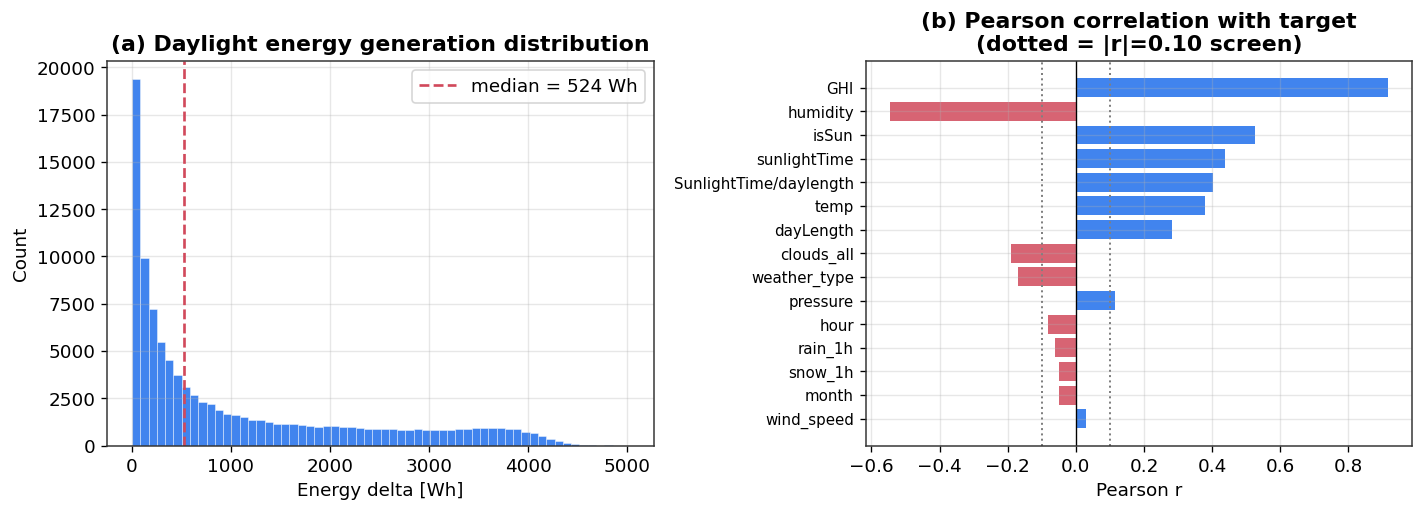

In [4]:
import os
os.makedirs(FIGDIR, exist_ok=True)
cor_target = make_eda_figure(df)
RESULTS = {}
RESULTS['data_info'] = DATA_INFO
RESULTS['corr_with_target'] = {k: round(float(v),4) for k,v in cor_target.items()}

## 3. Stage-1 relevance pre-screen
Features whose absolute Pearson correlation with the target is below a threshold
$\tau = 0.10$ carry negligible linear information and are removed before the
combinatorial search, reducing the QUBO to the informative subset:

$$\mathcal{F}_{\text{keep}} = \{\, f_i : |\rho(f_i, y)| \ge \tau \,\}.$$

In [5]:
KEPT, DROPPED = relevance_prescreen(df, thresh=0.10)
n = len(KEPT)
print('Kept (n=%d):'%n, KEPT)
print('Dropped:', DROPPED)
RESULTS['prescreen'] = dict(kept=KEPT, dropped=DROPPED, n_kept=n)

Kept (n=10): ['GHI', 'temp', 'pressure', 'humidity', 'clouds_all', 'isSun', 'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'weather_type']
Dropped: [('wind_speed', 0.029), ('rain_1h', 0.06), ('snow_1h', 0.051), ('hour', 0.081), ('month', 0.049)]


## 4. Feature selection as a QUBO
Let $x_i \in \{0,1\}$ indicate selection of feature $f_i$. With relevance
$r_i = |\rho(f_i,y)|$ (normalised) and redundancy $q_{ij} = |\rho(f_i,f_j)|$, we
minimise

$$H(\mathbf{x}) = -\alpha \sum_i r_i x_i \;+\; \beta \sum_{i<j} q_{ij} x_i x_j
\;+\; \gamma\Big(\sum_i x_i - k\Big)^2 .$$

The first term rewards relevance, the second penalises redundant pairs, and the
third enforces a target cardinality $k$. We use $\alpha=4,\ \beta=1,\ \gamma=2,\ k=5$.
Because $n=10$, the $2^{10}=1024$ configurations admit an exact brute-force optimum
used as ground truth for the approximation ratio.

In [6]:
r, Q = relevance_redundancy(df, KEPT)
ALPHA, BETA, GAMMA, KCARD = 4.0, 1.0, 2.0, 5
H, CONST = build_qubo(r, Q, k=KCARD, alpha=ALPHA, beta=BETA, gamma=GAMMA)
E_OPT, X_OPT = brute_force_optimum(H, CONST, n)
OPT_FEATURES = [KEPT[i] for i in range(n) if X_OPT[i]]
f_energy = lambda x: qubo_energy(x, H, CONST)
print('Global optimum energy = %.4f' % E_OPT)
print('Optimal subset:', OPT_FEATURES)
RESULTS['qubo'] = dict(alpha=ALPHA, beta=BETA, gamma=GAMMA, k=KCARD,
    relevance={KEPT[i]: round(float(r[i]),4) for i in range(n)},
    E_opt=round(float(E_OPT),6), optimal_features=OPT_FEATURES, n_states=int(2**n))

Global optimum energy = -7.6314
Optimal subset: ['GHI', 'temp', 'humidity', 'clouds_all', 'isSun']


## 5. Optimizers on the QUBO
All optimizers minimise the same $H(\mathbf{x})$. **GA** and **PSO** are classical
baselines. **QPSO** samples positions from a delta-potential well; **QIEA** and
**QGA** evolve *qubit* chromosomes updated by a rotation gate (and, for QGA, a
quantum crossover). Each is run with 10 random seeds (population 24, 50 iterations).

In [7]:
import time
N_SEEDS, POP, ITERS = 10, 24, 50
opt_summary, curves = {}, {}
for name, cls in ALGOS.items():
    es, times, best_e = [], [], 1e18
    for s in range(N_SEEDS):
        t0=time.time(); res=cls(f_energy, n, pop=POP, iters=ITERS, seed=s).run()
        times.append(time.time()-t0); es.append(res['energy'])
        if res['energy']<best_e: best_e,best_curve,best_x = res['energy'],res['curve'],res['x']
    es=np.array(es); hit=int(np.sum(np.abs(es-E_OPT)<1e-6))
    sel=[KEPT[i] for i in range(n) if best_x[i]]
    opt_summary[name]=dict(mean=float(es.mean()),std=float(es.std()),best=float(es.min()),
        hit=hit,n_seeds=N_SEEDS,approx_ratio=float(es.mean()/E_OPT),
        time_ms=float(np.mean(times)*1000),selected=sel,n_sel=int(sum(best_x)))
    curves[name]=[float(v) for v in best_curve]
    print(f'{name:5s} mean={es.mean():.4f} std={es.std():.4f} hit={hit}/{N_SEEDS} approx={es.mean()/E_OPT:.4f}')

GA    mean=-7.6314 std=0.0000 hit=10/10 approx=1.0000
PSO   mean=-7.6314 std=0.0000 hit=10/10 approx=1.0000


QPSO  mean=-7.6135 std=0.0538 hit=9/10 approx=0.9976
QIEA  mean=-7.6282 std=0.0097 hit=9/10 approx=0.9996


QGA   mean=-7.6314 std=0.0000 hit=10/10 approx=1.0000


## 6. QAOA (gate-based quantum optimization)
The QUBO is mapped to an Ising Hamiltonian $H_C=\sum_i h_i Z_i+\sum_{i<j}J_{ij}Z_iZ_j$.
A depth-$p$ QAOA prepares $|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle$ by
alternating the cost unitary $e^{-i\gamma_\ell H_C}$ and mixer
$e^{-i\beta_\ell \sum_i X_i}$ from $|+\rangle^{\otimes n}$. Parameters are trained with
Adam (exact statevector simulation); the lowest-energy bitstring among the most
probable outcomes is returned. We use the best of 5 restarts at $p=1$.

In [8]:
t0=time.time(); qaoa = run_qaoa_best(H, CONST, n, p=1, nseeds=5, steps=50); qt=time.time()-t0
qsel=[KEPT[i] for i in range(n) if qaoa['x'][i]]; qhit=int(abs(qaoa['energy']-E_OPT)<1e-6)
opt_summary['QAOA']=dict(mean=float(qaoa['energy']),std=0.0,best=float(qaoa['energy']),hit=qhit,
    n_seeds=5,approx_ratio=float(qaoa['energy']/E_OPT),time_ms=float(qt*1000),selected=qsel,
    n_sel=int(qaoa['x'].sum()),expval=float(qaoa['expval']))
curves['QAOA']=[float(v) for v in qaoa['curve']]
RESULTS['optimizers']=opt_summary; RESULTS['curves']=curves
print(f"QAOA E={qaoa['energy']:.4f} hit={qhit} approx={qaoa['energy']/E_OPT:.4f} sel={qsel} t={qt:.1f}s")

QAOA E=-7.6314 hit=1 approx=1.0000 sel=['GHI', 'temp', 'humidity', 'clouds_all', 'isSun'] t=48.2s


## 7. Optimizer comparison — convergence and multi-criteria radar

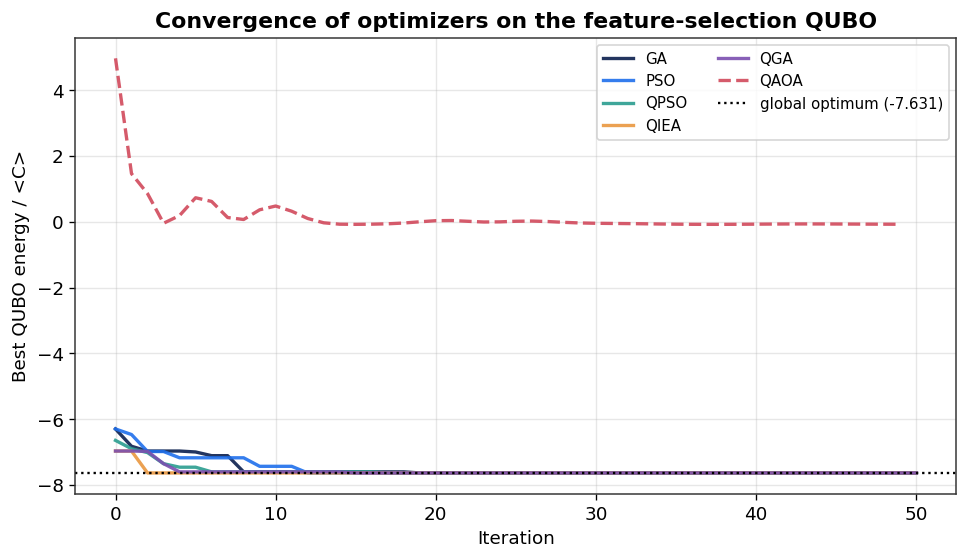

In [9]:
colmap=dict(GA=NAVY,PSO=BLUE,QPSO=GREEN,QIEA=ORANGE,QGA=PURPLE,QAOA=RED)
fig,ax=plt.subplots(figsize=(8.2,4.8))
for name,cv in curves.items():
    ax.plot(np.arange(len(cv)),cv,label=name,color=colmap.get(name),lw=2,ls='--' if name=='QAOA' else '-',alpha=0.9)
ax.axhline(E_OPT,color='k',ls=':',lw=1.4,label=f'global optimum ({E_OPT:.3f})')
ax.set_xlabel('Iteration'); ax.set_ylabel('Best QUBO energy / <C>')
ax.set_title('Convergence of optimizers on the feature-selection QUBO',fontweight='bold')
ax.legend(ncol=2,fontsize=9); plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_convergence.png',bbox_inches='tight'); plt.show()

In [10]:
print('%-6s %-9s %-6s %-9s %-9s'%('opt','approx','hit','time_ms','nsel'))
for nm in ['GA','PSO','QPSO','QIEA','QGA','QAOA']:
    d=opt_summary[nm]; print('%-6s %-9.4f %-6s %-9.1f %-9d'%(nm,d['approx_ratio'],f"{d['hit']}/{d['n_seeds']}",d['time_ms'],d['n_sel']))

opt    approx    hit    time_ms   nsel     
GA     1.0000    10/10  62.1      5        
PSO    1.0000    10/10  10.1      5        
QPSO   0.9976    9/10   48.1      5        
QIEA   0.9996    9/10   17.9      5        
QGA    1.0000    10/10  25.0      5        
QAOA   1.0000    1/5    48185.7   5        


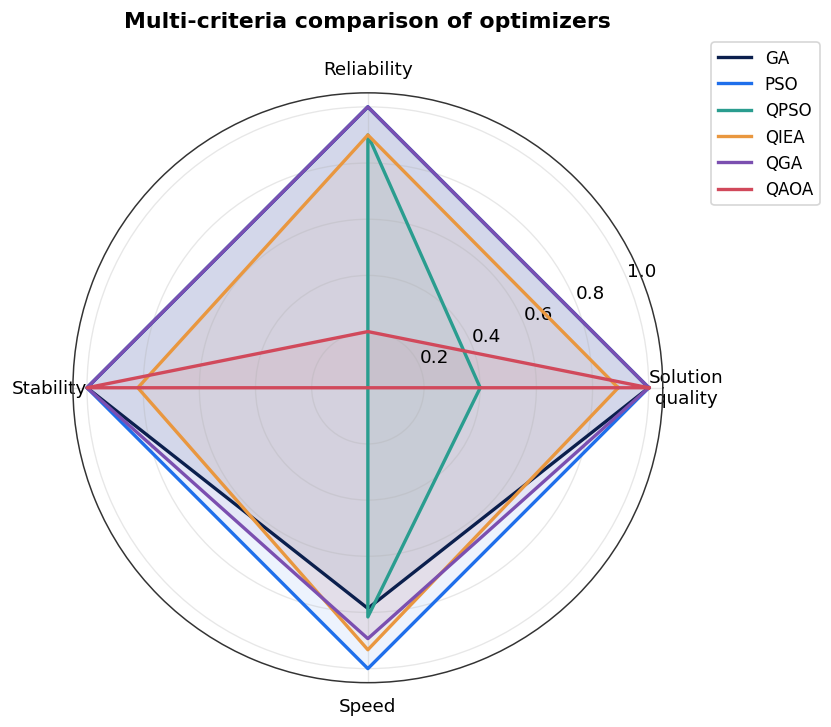

In [11]:
names=['GA','PSO','QPSO','QIEA','QGA','QAOA']
quality=np.array([opt_summary[nm]['approx_ratio'] for nm in names])
reliab=np.array([opt_summary[nm]['hit']/opt_summary[nm]['n_seeds'] for nm in names])
stds=np.array([opt_summary[nm]['std'] for nm in names])
stability=1-(stds-stds.min())/(stds.max()-stds.min()+1e-12)
times=np.array([opt_summary[nm]['time_ms'] for nm in names])
speed=1-(np.log10(times)-np.log10(times).min())/(np.log10(times).max()-np.log10(times).min()+1e-12)
labels=['Solution\nquality','Reliability','Stability','Speed']
data=np.vstack([quality,reliab,stability,speed]).T
q=data[:,0]; data[:,0]=(q-q.min())/(q.max()-q.min()+1e-12)*0.6+0.4
ang=np.linspace(0,2*np.pi,len(labels),endpoint=False).tolist(); ang+=ang[:1]
fig,ax=plt.subplots(figsize=(7.2,7.2),subplot_kw=dict(polar=True))
for i,nm in enumerate(names):
    v=data[i].tolist(); v+=v[:1]; ax.plot(ang,v,color=colmap[nm],lw=2,label=nm); ax.fill(ang,v,color=colmap[nm],alpha=0.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels,fontsize=11); ax.set_ylim(0,1.05)
ax.set_title('Multi-criteria comparison of optimizers',fontweight='bold',pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.28,1.10),fontsize=10)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_radar.png',bbox_inches='tight'); plt.show()
RESULTS['radar']=dict(names=names,quality=quality.tolist(),reliability=reliab.tolist(),stability=stability.tolist(),speed=speed.tolist())

## 8. Downstream forecasting
Each selected subset trains a `HistGradientBoostingRegressor` to predict
`Energy delta[Wh]` under a **chronological 80/20 split** (train on the earlier
period, test on the later). We report RMSE, MAE and $R^2$, and compare the compact
QUBO-optimal set against the full pre-screened set.

In [12]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
split=int(0.8*len(df)); tr_df,te_df=df.iloc[:split],df.iloc[split:]
SPLIT_DATE=str(tr_df['Time'].max())
def forecast_subset(features):
    m=HistGradientBoostingRegressor(max_iter=200,max_depth=8,learning_rate=0.08,random_state=0)
    m.fit(tr_df[features].values, tr_df[TARGET].values)
    pred=m.predict(te_df[features].values); yte=te_df[TARGET].values
    return dict(rmse=float(np.sqrt(mean_squared_error(yte,pred))),mae=float(mean_absolute_error(yte,pred)),r2=float(r2_score(yte,pred))),pred,yte,m
forecast={}; subset_map={nm:opt_summary[nm]['selected'] for nm in opt_summary}
subset_map['ALL10']=KEPT; subset_map['OPTIMAL']=OPT_FEATURES
for nm,feats in subset_map.items():
    mt,_,_,_=forecast_subset(feats); forecast[nm]=dict(metrics=mt,n_feat=len(feats),features=feats)
    print(f'{nm:8s} feats={len(feats)} RMSE={mt["rmse"]:.2f} MAE={mt["mae"]:.2f} R2={mt["r2"]:.4f}')
RESULTS['forecast']=forecast; RESULTS['forecast_split_date']=SPLIT_DATE

GA       feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


PSO      feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


QPSO     feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


QIEA     feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


QGA      feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


QAOA     feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


ALL10    feats=10 RMSE=322.51 MAE=130.60 R2=0.9050


OPTIMAL  feats=5 RMSE=405.72 MAE=189.15 R2=0.8497


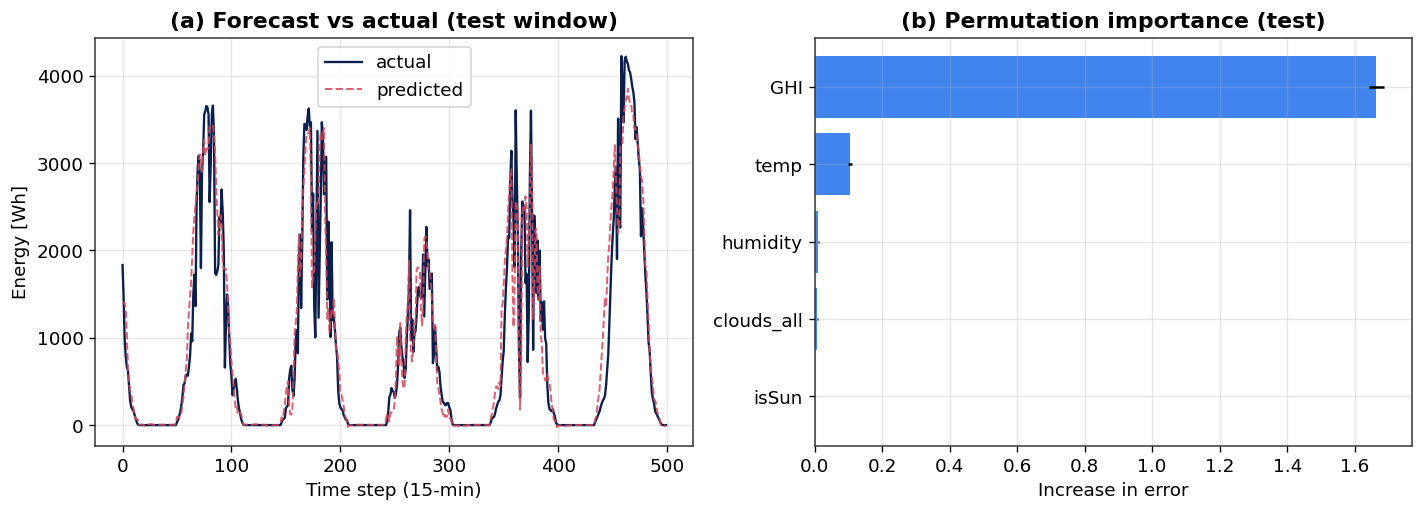

In [13]:
om,opt_pred,opt_yte,opt_model=forecast_subset(OPT_FEATURES)
fig,ax=plt.subplots(1,2,figsize=(12,4.4))
idx=np.arange(2000,2500)
ax[0].plot(opt_yte[idx],color=NAVY,lw=1.4,label='actual'); ax[0].plot(opt_pred[idx],color=RED,lw=1.2,ls='--',alpha=0.85,label='predicted')
ax[0].set_title('(a) Forecast vs actual (test window)',fontweight='bold'); ax[0].set_xlabel('Time step (15-min)'); ax[0].set_ylabel('Energy [Wh]'); ax[0].legend()
sub=np.random.default_rng(0).choice(len(opt_yte),size=3000,replace=False)
pi=permutation_importance(opt_model,te_df[OPT_FEATURES].values[sub],opt_yte[sub],n_repeats=3,random_state=0)
order=np.argsort(pi.importances_mean)
ax[1].barh(range(len(OPT_FEATURES)),pi.importances_mean[order],color=BLUE,alpha=0.85,xerr=pi.importances_std[order])
ax[1].set_yticks(range(len(OPT_FEATURES))); ax[1].set_yticklabels([OPT_FEATURES[i] for i in order])
ax[1].set_title('(b) Permutation importance (test)',fontweight='bold'); ax[1].set_xlabel('Increase in error')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_forecast.png',bbox_inches='tight'); plt.show()
RESULTS['forecast']['OPTIMAL']['perm_importance']={OPT_FEATURES[i]:round(float(pi.importances_mean[i]),3) for i in range(len(OPT_FEATURES))}

## 9. Variational Quantum Classifier (VQC)
As a quantum *learning* component we classify, among daylight samples, whether
generation is **high** or **low** relative to the daytime median (524 Wh). Four
features (GHI, temp, humidity, clouds\_all) are angle-embedded on 4 qubits, followed
by `StronglyEntanglingLayers` and a $Z_0$ parity read-out trained with cross-entropy.
We use $L=3$ entangling layers and compare against classical baselines.

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
day=df[df['isSun']==1].copy(); MED=float(day[TARGET].median()); day['label']=(day[TARGET]>=MED).astype(int)
ds=int(0.8*len(day)); dtr,dte=day.iloc[:ds],day.iloc[ds:]
VF=['GHI','temp','humidity','clouds_all']; scaler=StandardScaler().fit(dtr[VF].values)
enc=lambda X: np.clip(scaler.transform(X),-3,3)/3*np.pi
def bal(d,ntot,rs=1):
    a=d[d.label==1].sample(ntot//2,random_state=rs); b=d[d.label==0].sample(ntot//2,random_state=rs)
    return pd.concat([a,b]).sample(frac=1,random_state=rs+1)
trs,tes=bal(dtr,600),bal(dte,400)
Xtr_v,ytr_v=enc(trs[VF].values),trs['label'].values; Xte_v,yte_v=enc(tes[VF].values),tes['label'].values
t0=time.time(); vqc=run_vqc(Xtr_v,ytr_v,Xte_v,yte_v,n_qubits=4,layers=3,steps=70,seed=0); vt=time.time()-t0
base={}
for bn,clf in [('LogReg',LogisticRegression(max_iter=1000)),('SVM-RBF',SVC()),('HGB-clf',HistGradientBoostingClassifier(max_iter=150,random_state=0))]:
    clf.fit(Xtr_v,ytr_v); base[bn]=float((clf.predict(Xte_v)==yte_v).mean())
print(f"VQC L=3 acc={vqc['test']['acc']:.3f} F1={vqc['test']['f1']:.3f} AUC={vqc['test']['auc']:.3f} t={vt:.1f}s")
print('baselines',{k:round(v,3) for k,v in base.items()})
RESULTS['vqc']=dict(features=VF,median_threshold=MED,n_train=len(trs),n_test=len(tes),train=vqc['train'],test=vqc['test'],baselines={k:round(v,4) for k,v in base.items()},time_s=round(vt,1),curve=[float(x) for x in vqc['curve']])

VQC L=3 acc=0.875 F1=0.872 AUC=0.947 t=115.5s
baselines {'LogReg': 0.875, 'SVM-RBF': 0.885, 'HGB-clf': 0.868}


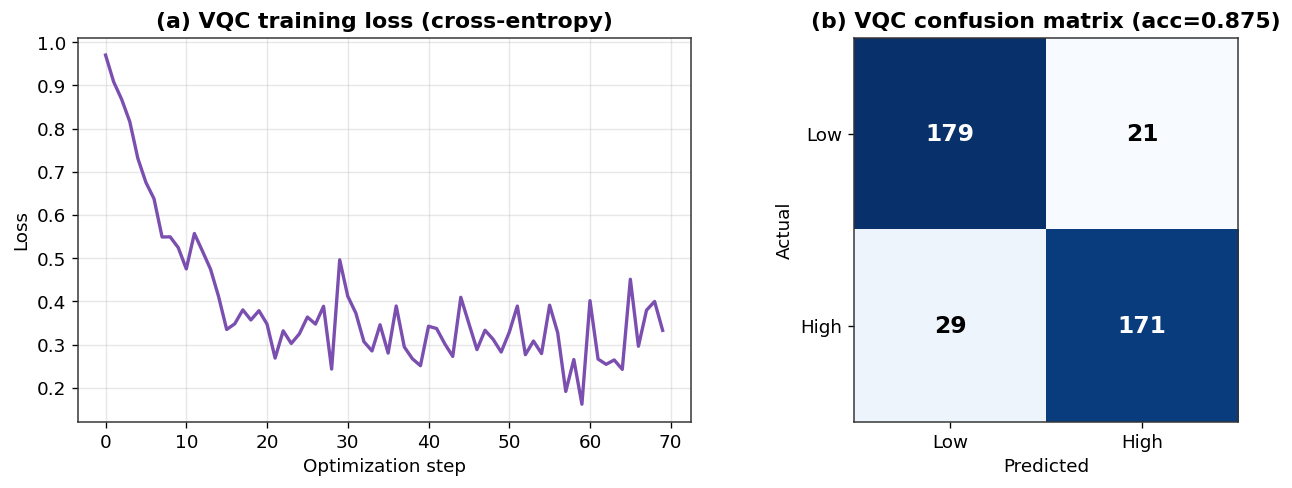

In [15]:
fig,ax=plt.subplots(1,2,figsize=(11.5,4.2))
ax[0].plot(vqc['curve'],color=PURPLE,lw=2); ax[0].set_title('(a) VQC training loss (cross-entropy)',fontweight='bold'); ax[0].set_xlabel('Optimization step'); ax[0].set_ylabel('Loss')
cm=np.array(vqc['test']['cm']); ax[1].imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):
        ax[1].text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black',fontsize=14,fontweight='bold')
ax[1].set_xticks([0,1]); ax[1].set_yticks([0,1]); ax[1].set_xticklabels(['Low','High']); ax[1].set_yticklabels(['Low','High'])
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Actual'); ax[1].set_title(f"(b) VQC confusion matrix (acc={vqc['test']['acc']:.3f})",fontweight='bold'); ax[1].grid(False)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_vqc.png',bbox_inches='tight'); plt.show()

## 10. Ablation studies
We probe five design axes: (a) cardinality $k$, (b) redundancy weight $\beta$,
(c) QAOA depth $p$, (d) VQC entangling-layer depth $L$, and (e) the QGA rotation
angle $\theta$.

In [16]:
# (a) cardinality k
abl_k={}
for kk in [3,4,5,6,7]:
    Hk,Ck=build_qubo(r,Q,k=kk,alpha=ALPHA,beta=BETA,gamma=GAMMA); Ek,Xk=brute_force_optimum(Hk,Ck,n)
    selk=[KEPT[i] for i in range(n) if Xk[i]]; mk,_,_,_=forecast_subset(selk)
    abl_k[str(kk)]=dict(n_sel=int(Xk.sum()),selected=selk,rmse=mk['rmse'],mae=mk['mae'],r2=mk['r2'],E_opt=float(Ek))
    print(f'k={kk} nsel={int(Xk.sum())} RMSE={mk["rmse"]:.2f} R2={mk["r2"]:.4f}')

k=3 nsel=3 RMSE=453.05 R2=0.8126


k=4 nsel=4 RMSE=452.49 R2=0.8131


k=5 nsel=5 RMSE=405.72 R2=0.8497


k=6 nsel=6 RMSE=403.07 R2=0.8517


k=7 nsel=7 RMSE=348.52 R2=0.8891


In [17]:
# (b) redundancy weight beta
abl_beta={}
for bb in [0.0,0.5,1.0,2.0]:
    Hb,Cb=build_qubo(r,Q,k=KCARD,alpha=ALPHA,beta=bb,gamma=GAMMA); Eb,Xb=brute_force_optimum(Hb,Cb,n)
    selb=[KEPT[i] for i in range(n) if Xb[i]]; mb,_,_,_=forecast_subset(selb)
    idxs=[KEPT.index(fx) for fx in selb]
    red=float(np.mean([Q[a,b] for a in idxs for b in idxs if a<b])) if len(idxs)>1 else 0.0
    abl_beta[str(bb)]=dict(n_sel=int(Xb.sum()),selected=selb,rmse=mb['rmse'],r2=mb['r2'],mean_redundancy=round(red,4))
    print(f'beta={bb} nsel={int(Xb.sum())} redun={red:.3f} RMSE={mb["rmse"]:.2f} R2={mb["r2"]:.4f}')

beta=0.0 nsel=5 redun=0.620 RMSE=332.33 R2=0.8992


beta=0.5 nsel=5 redun=0.533 RMSE=380.25 R2=0.8680


beta=1.0 nsel=5 redun=0.354 RMSE=405.72 R2=0.8497


beta=2.0 nsel=5 redun=0.219 RMSE=407.95 R2=0.8481


In [18]:
# (c) QAOA depth p
abl_qaoa={}
for pp in [1,2,3]:
    t0=time.time(); rq=run_qaoa_best(H,CONST,n,p=pp,nseeds=3,steps=50); dt=time.time()-t0
    abl_qaoa[str(pp)]=dict(energy=float(rq['energy']),approx_ratio=float(rq['energy']/E_OPT),hit=int(abs(rq['energy']-E_OPT)<1e-6),expval=float(rq['expval']),time_s=round(dt,1),n_params=2*pp)
    print(f'p={pp} E={rq["energy"]:.4f} approx={rq["energy"]/E_OPT:.4f} hit={abl_qaoa[str(pp)]["hit"]} t={dt:.1f}s')

p=1 E=-7.6314 approx=1.0000 hit=1 t=29.6s


p=2 E=-7.4571 approx=0.9772 hit=0 t=46.1s


p=3 E=-7.6314 approx=1.0000 hit=1 t=63.1s


In [19]:
# (d) VQC depth L
abl_vqc={}
for LL in [1,2]:
    rv=run_vqc(Xtr_v,ytr_v,Xte_v,yte_v,n_qubits=4,layers=LL,steps=70,seed=0)
    abl_vqc[str(LL)]=dict(acc=rv['test']['acc'],f1=rv['test']['f1'],auc=rv['test']['auc'])
    print(f'L={LL} acc={rv["test"]["acc"]:.3f} F1={rv["test"]["f1"]:.3f} AUC={rv["test"]["auc"]:.3f}')
abl_vqc['3']=dict(acc=vqc['test']['acc'],f1=vqc['test']['f1'],auc=vqc['test']['auc'])
print(f"L=3 acc={vqc['test']['acc']:.3f} (main)")

L=1 acc=0.620 F1=0.631 AUC=0.668


L=2 acc=0.765 F1=0.766 AUC=0.848
L=3 acc=0.875 (main)


In [20]:
# (e) QGA rotation angle theta
abl_theta={}
for thf in [0.01,0.025,0.05,0.10]:
    th=thf*np.pi; es=np.array([QGA(f_energy,n,pop=24,iters=50,theta=th,seed=s).run()['energy'] for s in range(10)])
    abl_theta[str(thf)]=dict(mean=float(es.mean()),std=float(es.std()),hit=int(np.sum(np.abs(es-E_OPT)<1e-6)))
    print(f'theta={thf}*pi mean={es.mean():.4f} std={es.std():.4f} hit={abl_theta[str(thf)]["hit"]}/10')
RESULTS['ablation']=dict(cardinality_k=abl_k,redundancy_beta=abl_beta,qaoa_depth=abl_qaoa,vqc_depth=abl_vqc,qga_theta=abl_theta)

theta=0.01*pi mean=-7.6314 std=0.0000 hit=10/10


theta=0.025*pi mean=-7.6282 std=0.0097 hit=9/10


theta=0.05*pi mean=-7.6314 std=0.0000 hit=10/10


theta=0.1*pi mean=-7.6068 std=0.0539 hit=7/10


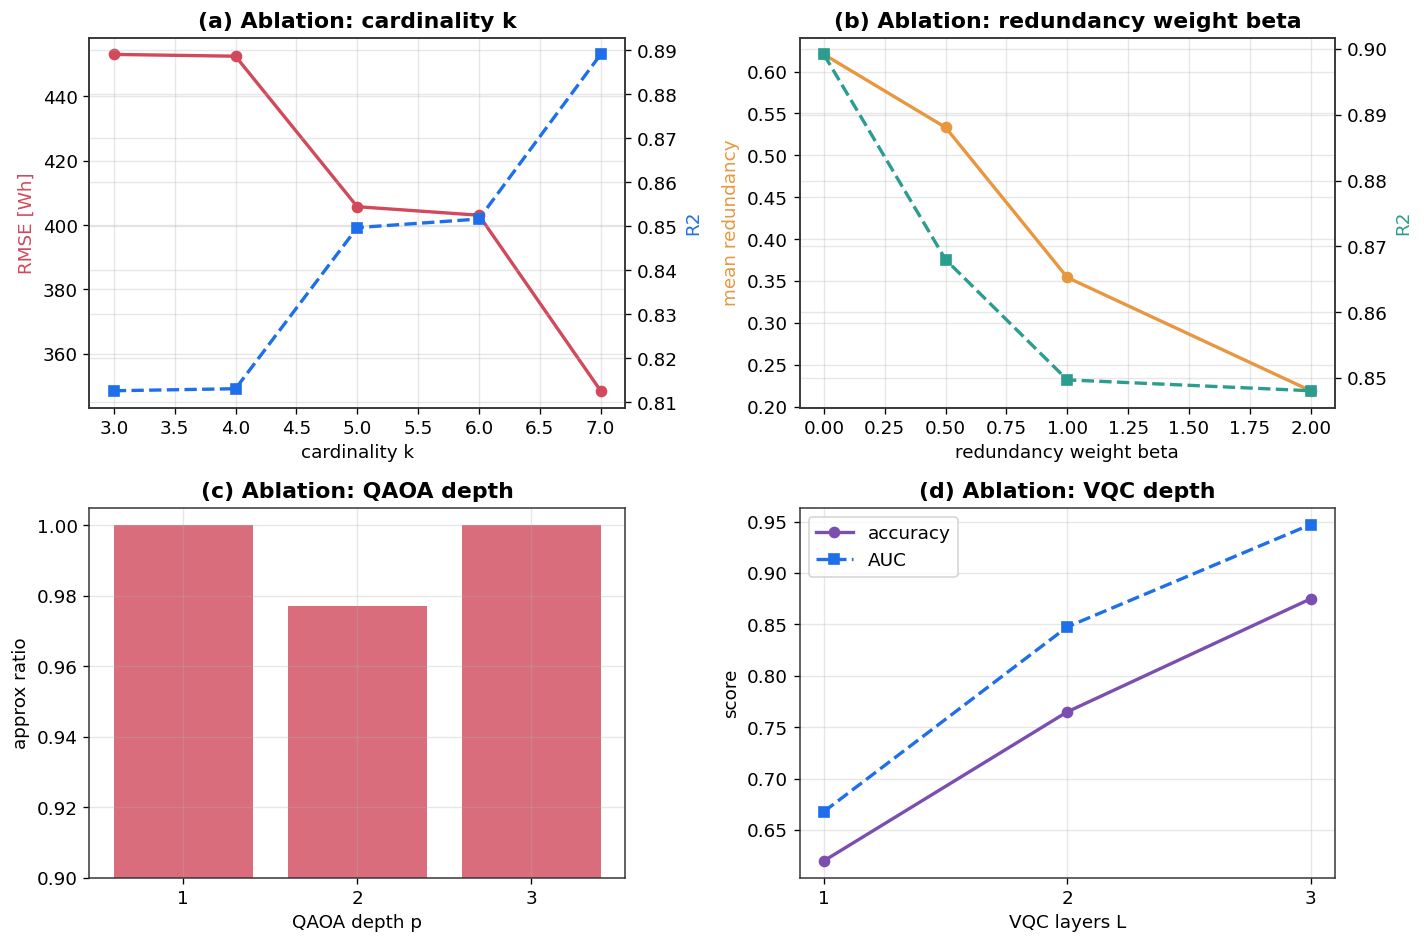

In [21]:
fig,ax=plt.subplots(2,2,figsize=(12,8))
ks=sorted(abl_k,key=lambda z:int(z)); a0=ax[0,0]; a0b=a0.twinx()
a0.plot([int(k) for k in ks],[abl_k[k]['rmse'] for k in ks],'o-',color=RED,lw=2); a0b.plot([int(k) for k in ks],[abl_k[k]['r2'] for k in ks],'s--',color=BLUE,lw=2)
a0.set_xlabel('cardinality k'); a0.set_ylabel('RMSE [Wh]',color=RED); a0b.set_ylabel('R2',color=BLUE); a0.set_title('(a) Ablation: cardinality k',fontweight='bold')
bs=sorted(abl_beta,key=lambda z:float(z)); a1=ax[0,1]; a1b=a1.twinx()
a1.plot([float(b) for b in bs],[abl_beta[b]['mean_redundancy'] for b in bs],'o-',color=ORANGE,lw=2); a1b.plot([float(b) for b in bs],[abl_beta[b]['r2'] for b in bs],'s--',color=GREEN,lw=2)
a1.set_xlabel('redundancy weight beta'); a1.set_ylabel('mean redundancy',color=ORANGE); a1b.set_ylabel('R2',color=GREEN); a1.set_title('(b) Ablation: redundancy weight beta',fontweight='bold')
ps=sorted(abl_qaoa,key=lambda z:int(z)); ax[1,0].bar(ps,[abl_qaoa[p]['approx_ratio'] for p in ps],color=RED,alpha=0.8); ax[1,0].set_ylim(0.9,1.005)
ax[1,0].set_xlabel('QAOA depth p'); ax[1,0].set_ylabel('approx ratio'); ax[1,0].set_title('(c) Ablation: QAOA depth',fontweight='bold')
Ls=sorted(abl_vqc,key=lambda z:int(z)); ax[1,1].plot([int(L) for L in Ls],[abl_vqc[L]['acc'] for L in Ls],'o-',color=PURPLE,lw=2,label='accuracy'); ax[1,1].plot([int(L) for L in Ls],[abl_vqc[L]['auc'] for L in Ls],'s--',color=BLUE,lw=2,label='AUC')
ax[1,1].set_xticks([int(L) for L in Ls]); ax[1,1].set_xlabel('VQC layers L'); ax[1,1].set_ylabel('score'); ax[1,1].legend(); ax[1,1].set_title('(d) Ablation: VQC depth',fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_ablation.png',bbox_inches='tight'); plt.show()

## 11. Pipeline architecture

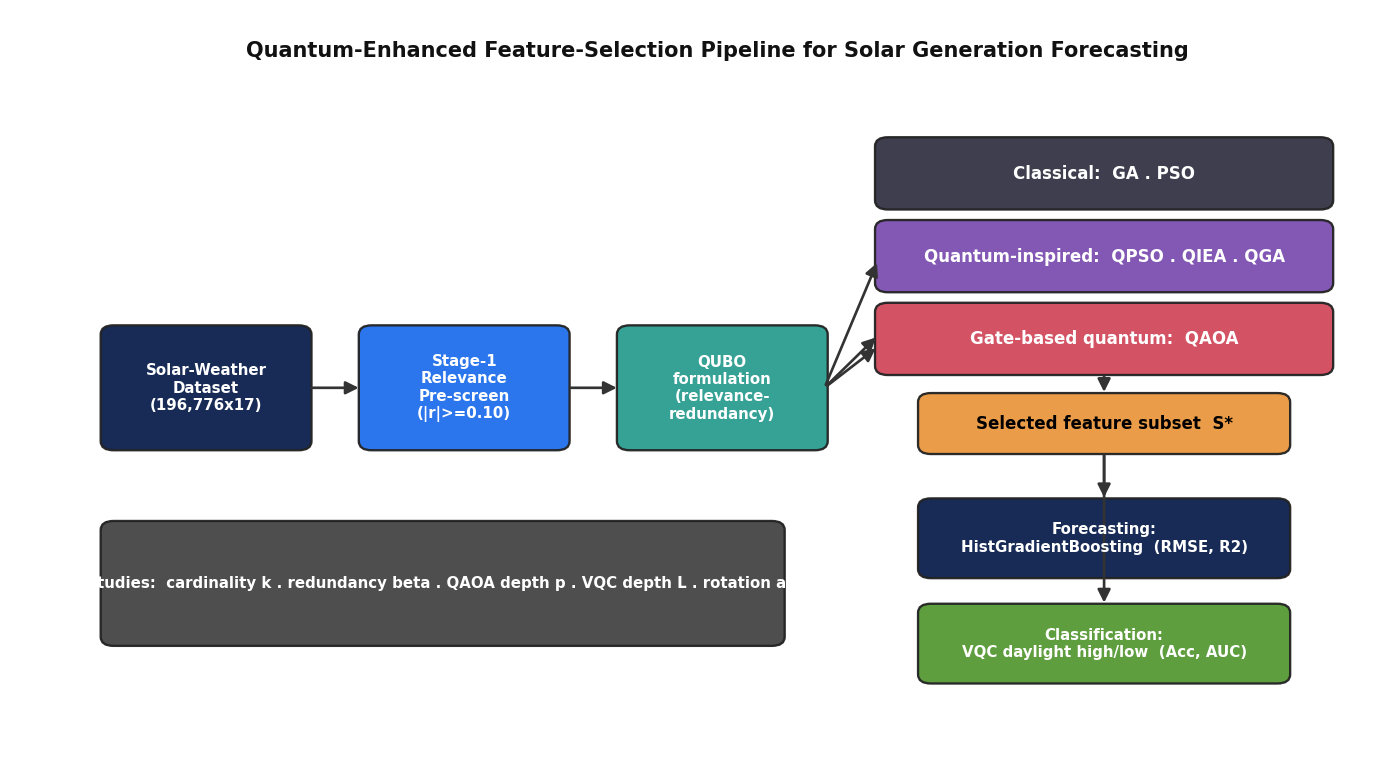

In [22]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig,ax=plt.subplots(figsize=(12,6.6)); ax.axis('off'); ax.set_xlim(0,12); ax.set_ylim(0,10)
def box(x,y,w,h,text,fc,tc='white',fs=10):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.03,rounding_size=0.12',linewidth=1.4,edgecolor='#222',facecolor=fc,alpha=0.95))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',color=tc,fontsize=fs,fontweight='bold')
def arrow(x1,y1,x2,y2):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=16,lw=1.6,color='#333'))
box(0.3,4.2,1.9,1.6,'Solar-Weather\nDataset\n(196,776x17)',NAVY,fs=9)
box(2.7,4.2,1.9,1.6,'Stage-1\nRelevance\nPre-screen\n(|r|>=0.10)',BLUE,fs=9)
box(5.1,4.2,1.9,1.6,'QUBO\nformulation\n(relevance-\nredundancy)',GREEN,fs=9)
box(7.5,7.4,4.2,0.9,'Classical:  GA . PSO','#333344')
box(7.5,6.3,4.2,0.9,'Quantum-inspired:  QPSO . QIEA . QGA',PURPLE)
box(7.5,5.2,4.2,0.9,'Gate-based quantum:  QAOA',RED)
box(7.9,4.15,3.4,0.75,'Selected feature subset  S*',ORANGE,tc='black',fs=10)
box(7.9,2.5,3.4,1.0,'Forecasting:\nHistGradientBoosting  (RMSE, R2)',NAVY,fs=9)
box(7.9,1.1,3.4,1.0,'Classification:\nVQC daylight high/low  (Acc, AUC)','#559933',fs=9)
box(0.3,1.6,6.3,1.6,'Ablation studies:  cardinality k . redundancy beta . QAOA depth p . VQC depth L . rotation angle theta','#444444',fs=9)
arrow(2.2,5.0,2.7,5.0); arrow(4.6,5.0,5.1,5.0)
arrow(7.0,5.0,7.5,5.7); arrow(7.0,5.0,7.5,6.7); arrow(7.0,5.0,7.5,5.55)
arrow(9.6,5.2,9.6,4.9); arrow(9.6,4.15,9.6,3.5); arrow(9.6,4.15,9.6,2.1)
ax.text(6,9.4,'Quantum-Enhanced Feature-Selection Pipeline for Solar Generation Forecasting',ha='center',fontsize=12.5,fontweight='bold',color='#111')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_architecture.png',bbox_inches='tight'); plt.show()

## 12. Persist all results
Every reported value is serialised to `results.json`.

In [23]:
import json
with open('results.json','w') as fh: json.dump(RESULTS,fh,indent=2,default=float)
print('Saved results.json with keys:', list(RESULTS.keys()))
print('Figures:', sorted(os.listdir(FIGDIR)))

Saved results.json with keys: ['data_info', 'corr_with_target', 'prescreen', 'qubo', 'optimizers', 'curves', 'radar', 'forecast', 'forecast_split_date', 'vqc', 'ablation']
Figures: ['fig_ablation.png', 'fig_architecture.png', 'fig_convergence.png', 'fig_eda.png', 'fig_forecast.png', 'fig_radar.png', 'fig_vqc.png']


## 13. Revision analyses (reviewer responses)

The cells below were added during revision to address reviewer comments. They reuse the objects defined above (`df`, `KEPT`, `TARGET`, `build_qubo`, `brute_force_optimum`, `forecast_subset`, `OPT_FEATURES`, `E_OPT`, `RESULTS`) and extend `RESULTS['revision_analyses']`.

* **R5.2 Data leakage** - recompute the Stage-1 screen and QUBO on the training partition only.
* **R5.4 Conventional feature selection** - mRMR, mutual information, RFE, L1/Lasso at k=5.
* **R5.1 Naive forecasting baselines** - persistence, seasonal persistence, climatology.
* **R5.3 Shift-invariant approximation ratio** - offset-invariant optimizer quality.

### 13.1 R5.2 - Leakage check: full-data vs training-only selection

In [ ]:
# Recompute Stage-1 screen and QUBO using TRAINING DATA ONLY (<= split date).
split_i = int(0.8*len(df)); tr_only = df.iloc[:split_i]
cor_full  = df[CANDIDATE_FEATURES+[TARGET]].corr().abs()[TARGET].drop(TARGET)
cor_train = tr_only[CANDIDATE_FEATURES+[TARGET]].corr().abs()[TARGET].drop(TARGET)
kept_full  = [f for f in CANDIDATE_FEATURES if cor_full[f]  >= 0.10]
kept_train = [f for f in CANDIDATE_FEATURES if cor_train[f] >= 0.10]

def solve_qubo_on(frame, feats, k=5, alpha=4.0, beta=1.0, gamma=2.0):
    r_, Q_ = relevance_redundancy(frame, feats)
    H_, C_ = build_qubo(r_, Q_, k=k, alpha=alpha, beta=beta, gamma=gamma)
    E_, X_ = brute_force_optimum(H_, C_, len(feats))
    return [feats[i] for i in range(len(feats)) if X_[i]]

sub_full  = solve_qubo_on(df,      KEPT)
sub_train = solve_qubo_on(tr_only, KEPT)
max_shift = float((cor_full - cor_train).abs().max())
print('max |delta corr| full vs train :', round(max_shift,4))
print('kept set identical             :', kept_full == kept_train)
print('QUBO optimal subset (full)     :', sub_full)
print('QUBO optimal subset (train)    :', sub_train)
print('optimal subset identical       :', set(sub_full)==set(sub_train))

RESULTS.setdefault('revision_analyses',{})['leakage_check'] = dict(
    corr_full={f:round(float(cor_full[f]),4) for f in CANDIDATE_FEATURES},
    corr_train={f:round(float(cor_train[f]),4) for f in CANDIDATE_FEATURES},
    max_abs_corr_shift=round(max_shift,4),
    kept_identical=bool(kept_full==kept_train),
    qubo_subset_full=sub_full, qubo_subset_train=sub_train,
    qubo_subset_identical=bool(set(sub_full)==set(sub_train)))

### 13.2 R5.4 - Conventional feature selection at matched cardinality (k=5)

In [ ]:
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

k = 5
Xtr = tr_df[KEPT].values; ytr = tr_df[TARGET].values   # tr_df/te_df from forecasting cell

# mutual information
mi = mutual_info_regression(Xtr, ytr, random_state=SEED)
mi_sel = [KEPT[i] for i in np.argsort(mi)[::-1][:k]]
# mRMR (MI relevance minus mean abs-corr redundancy, greedy)
relev = mi/(mi.max() if mi.max()>0 else 1.0)
Cf = np.abs(pd.DataFrame(Xtr, columns=KEPT).corr().values); np.fill_diagonal(Cf,0.0)
sel=[]; cand=list(range(len(KEPT)))
while len(sel)<k:
    scores=[(relev[c]-(np.mean([Cf[c,s] for s in sel]) if sel else 0.0), c) for c in cand]
    _,bi=max(scores); sel.append(bi); cand.remove(bi)
mrmr_sel=[KEPT[i] for i in sel]
# RFE (decision-tree estimator)
rfe=RFE(DecisionTreeRegressor(random_state=0), n_features_to_select=k).fit(StandardScaler().fit_transform(Xtr), ytr)
rfe_sel=[KEPT[i] for i in range(len(KEPT)) if rfe.support_[i]]
# L1 / Lasso (top-k by |coef|)
las=Lasso(alpha=0.01, max_iter=5000, random_state=0).fit(StandardScaler().fit_transform(Xtr), ytr)
l1_sel=[KEPT[i] for i in np.argsort(np.abs(las.coef_))[::-1][:k]]

fs_methods={'QUBO (beta=1)':OPT_FEATURES,'mRMR':mrmr_sel,'MutualInfo':mi_sel,'RFE':rfe_sel,'L1-Lasso':l1_sel}
fs_table={}
for name,feats in fs_methods.items():
    m,_,_,_=forecast_subset(feats)
    fs_table[name]=dict(features=feats, rmse=round(m['rmse'],2), mae=round(m['mae'],2), r2=round(m['r2'],4))
    print(f"{name:14s} R2={m['r2']:.4f} RMSE={m['rmse']:.2f}  {feats}")
RESULTS['revision_analyses']['conventional_fs_baselines']=fs_table

### 13.3 R5.1 - Naive forecasting baselines (persistence / seasonal / climatology)

In [ ]:
y_te = te_df[TARGET].values
# last-value persistence  y_t = y_{t-1}
prev = df[TARGET].shift(1).values[split_i:]; m1 = ~np.isnan(prev)
rmse_p = float(np.sqrt(mean_squared_error(y_te[m1], prev[m1]))); r2_p = float(r2_score(y_te[m1], prev[m1]))
# one-day seasonal persistence  y_t = y_{t-96}  (96 x 15min)
prevd = df[TARGET].shift(96).values[split_i:]; m2 = ~np.isnan(prevd)
rmse_s = float(np.sqrt(mean_squared_error(y_te[m2], prevd[m2]))); r2_s = float(r2_score(y_te[m2], prevd[m2]))
# climatology (training mean)
mean_pred = np.full_like(y_te, tr_df[TARGET].mean(), dtype=float)
rmse_c = float(np.sqrt(mean_squared_error(y_te, mean_pred))); r2_c = float(r2_score(y_te, mean_pred))
naive=dict(persistence_t_1=dict(rmse=round(rmse_p,2),r2=round(r2_p,4)),
           seasonal_persistence_t_96=dict(rmse=round(rmse_s,2),r2=round(r2_s,4)),
           climatology_mean=dict(rmse=round(rmse_c,2),r2=round(r2_c,4)))
for k_,v_ in naive.items(): print(f"{k_:28s} RMSE={v_['rmse']:8.2f}  R2={v_['r2']:.4f}")
RESULTS['revision_analyses']['naive_forecast_baselines']=naive

### 13.4 R5.3 - Shift-invariant approximation ratio

In [ ]:
# Enumerate all energies of the main QUBO to get E_min, E_max for an offset-invariant ratio.
all_E = np.array([qubo_energy(np.array([(m>>b)&1 for b in range(n)]), H, CONST) for m in range(1<<n)])
E_min, E_max = float(all_E.min()), float(all_E.max())
shift_inv = lambda E: float((E_max - E)/(E_max - E_min))
print(f'E_min={E_min:.4f}  E_max={E_max:.4f}')
ar={}
for nm,o in RESULTS['optimizers'].items():
    ar[nm]=dict(eta_old_best_over_opt=round(float(o['best']/E_OPT),4),
                eta_s_mean=round(shift_inv(o['mean']),4),
                eta_s_best=round(shift_inv(o['best']),4))
    print(f"{nm:5s} eta_s(mean)={ar[nm]['eta_s_mean']:.4f}  eta_s(best)={ar[nm]['eta_s_best']:.4f}")
RESULTS['revision_analyses']['shift_invariant_approx_ratio']=dict(E_min=round(E_min,4),E_max=round(E_max,4),
    note='eta_s=(E_max-E)/(E_max-E_min) in [0,1]; invariant to constant offset of H', optimizers=ar)

import json as _json
_json.dump(RESULTS, open('results.json','w'), indent=2)
print('results.json re-written with revision_analyses')